# 3주차 — Hugging Face 시작하기
### 남이 만든 AI 모델 가져다 쓰기 · 인공지능 플랫폼실습 · 인공지능소프트웨어과

---

## 이번 주 학습 목표
1. Hugging Face에서 공개된 모델을 코드로 불러올 수 있다.
2. `pipeline()` 으로 문장의 감정을 분석할 수 있다.
3. 모델 카드를 읽고 내가 쓸 모델을 골라 바꿔 낄 수 있다.

## 지난주와 무엇이 다른가
```
2주차 : 내가 사진을 모아서 → 내가 학습시키고 → 내가 만든 모델을 씀   (수십 분)
3주차 : 남이 이미 학습시켜 둔 모델을 → 이름만 적어서 → 바로 가져다 씀 (수십 초)
```

> ⏱ 예상 소요 시간: 약 90분
> ※ 모델을 인터넷에서 내려받으므로 **첫 실행은 1~3분** 걸립니다. 두 번째부터는 빠릅니다.


---
# STEP 1. 도구 준비하기  (약 10분)

`transformers` 는 Hugging Face가 만든 파이썬 라이브러리입니다.
공개된 AI 모델을 몇 줄로 불러 쓸 수 있게 해 줍니다.


In [32]:
# ============================================================
# [실습 1-1] transformers 설치 및 버전 확인
# ------------------------------------------------------------
# Colab에는 대부분 이미 설치되어 있지만, 버전이 낮으면 오류가 날 수 있어
# 최신 버전으로 맞춘 뒤 시작합니다.
#   -q : 설치 메시지를 조용히
#   -U : 이미 있으면 최신으로 올리기(update)
# ============================================================

!pip install -q -U transformers

import transformers, torch
print("transformers 버전 :", transformers.__version__)
print("torch 버전        :", torch.__version__)
print("GPU 사용 가능      :", torch.cuda.is_available())


transformers 버전 : 5.16.1
torch 버전        : 2.11.0+cu128
GPU 사용 가능      : True


> 💡 **GPU가 False여도 괜찮습니다.**
> 오늘 쓰는 모델은 작아서 CPU로도 몇 초면 끝납니다.
> (1주차에서 배운 대로 GPU를 켜면 조금 더 빨라집니다)


---
# STEP 2. 첫 번째 pipeline — 딱 3줄  (약 15분)

`pipeline()` 은 **모델 다운로드 → 문장 자르기 → 계산 → 결과 정리** 를
한 번에 처리해 주는 도구입니다. 우리는 "무슨 일을 할지"만 알려주면 됩니다.


In [33]:
# ============================================================
# [실습 2-1] 영어 문장의 감정 분석하기
# ------------------------------------------------------------
# 처음 실행하면 모델을 내려받느라 1~3분 걸립니다. 진행 막대가 나오면 정상입니다.
#
# "text-classification" = 문장을 분류하는 일
#   (예전 이름인 "sentiment-analysis" 로 적어도 똑같이 동작합니다)
# ============================================================

from transformers import pipeline

# 1) 무슨 일을 할지 정하기 -> 도구가 알아서 기본 모델을 내려받습니다
분류기 = pipeline("text-classification")

# 2) 문장을 넣기
결과 = 분류기("I love this class!")

# 3) 결과 보기
print(결과)


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998816251754761}]


### ✅ 확인 체크포인트
아래와 비슷한 결과가 나오면 성공입니다.

```
[{'label': 'POSITIVE', 'score': 0.9998}]
```

`label` 은 판단 결과, `score` 는 그렇게 판단한 확신의 정도(확률)입니다.


In [34]:
# ============================================================
# [실습 2-2] 어떤 모델이 쓰였는지 확인하기
# ------------------------------------------------------------
# 모델 이름을 안 적으면 pipeline이 기본 모델을 알아서 고릅니다.
# 실무에서는 "무슨 모델을 쓰는지 모르는 상태"가 위험하므로 항상 확인합니다.
# ============================================================

print("사용된 모델 :", 분류기.model.name_or_path)
print("이 모델이 낼 수 있는 답 :", 분류기.model.config.id2label)


사용된 모델 : distilbert/distilbert-base-uncased-finetuned-sst-2-english
이 모델이 낼 수 있는 답 : {0: 'NEGATIVE', 1: 'POSITIVE'}


---
# STEP 3. 결과를 제대로 읽는 법  (약 15분)

기본적으로 pipeline은 **가장 점수가 높은 답 하나만** 돌려줍니다.
모든 후보의 점수를 보고 싶으면 `top_k=None` 을 붙입니다.


In [35]:
# ============================================================
# [실습 3-1] 결과에서 값 꺼내기
# ------------------------------------------------------------
# 결과는 [ { ... } ] 형태입니다. 대괄호 안에 중괄호가 들어 있는 모양입니다.
#   결과[0]            -> 첫 번째 답 (중괄호 하나)
#   결과[0]["label"]   -> 그 답의 이름
#   결과[0]["score"]   -> 그 답의 점수
# ============================================================

결과 = 분류기("I love this class!")

print("전체 결과 :", 결과)
print("판단      :", 결과[0]["label"])
print("확률      :", round(결과[0]["score"] * 100, 2), "%")


전체 결과 : [{'label': 'POSITIVE', 'score': 0.9998816251754761}]
판단      : POSITIVE
확률      : 99.99 %


In [36]:
# ============================================================
# [실습 3-2] 모든 후보의 점수 보기  ★ top_k=None
# ------------------------------------------------------------
# ★ 주의 : 인터넷의 오래된 예제에는 return_all_scores=True 라고 적혀 있습니다.
#   최신 버전에서는 그 옵션이 무시되어 답이 하나만 나오고,
#   preds[0][1] 처럼 꺼내려 하면 KeyError: 1 오류가 납니다.
#   -> 지금은 top_k=None 을 쓰세요.
# ============================================================

전체 = 분류기("I love this class!", top_k=None)

print("모든 후보:")
for 항목 in 전체:
    print(f"  {항목['label']:10s} {항목['score']*100:6.2f} %")

합계 = sum(항목["score"] for 항목 in 전체)
print("\n점수의 합 :", round(합계, 4), "-> 항상 1(100%)이 됩니다")


모든 후보:
  POSITIVE    99.99 %
  NEGATIVE     0.01 %

점수의 합 : 1.0 -> 항상 1(100%)이 됩니다


---
# STEP 4. 여러 문장 한 번에  (약 10분)


In [37]:
# ============================================================
# [실습 4-1] 리스트로 여러 문장 넣기
# ------------------------------------------------------------
# 문장을 하나씩 넣는 것보다 리스트로 한 번에 넣는 편이 훨씬 빠릅니다.
# ============================================================

문장들 = [
    "This class is really fun.",
    "The homework is too hard.",
    "I am not sure about this.",
]

결과들 = 분류기(문장들)

for 문장, 결과 in zip(문장들, 결과들):
    print(f"[{결과['label']:8s} {결과['score']*100:5.1f}%]  {문장}")


[POSITIVE 100.0%]  This class is really fun.
[NEGATIVE 100.0%]  The homework is too hard.
[NEGATIVE 100.0%]  I am not sure about this.


> 💡 **세 번째 문장을 보세요.**
> "잘 모르겠다"는 애매한 문장인데도 AI는 POSITIVE 또는 NEGATIVE 중 하나를 고릅니다.
> 2주차에서 배운 것과 같습니다 — **AI는 배운 선택지 안에서만 답합니다.**


---
# STEP 5. 한국어 모델로 바꿔 끼우기  (약 20분)

기본 모델은 **영어 전용**입니다. 한국어를 넣으면 엉뚱한 답이 나옵니다.
한국어로 학습된 모델로 바꿔 봅시다. **바꿀 것은 모델 이름 한 줄뿐입니다.**


In [38]:
# ============================================================
# [실습 5-1] 영어 모델에 한국어를 넣으면?
# ------------------------------------------------------------
# 먼저 '왜 바꿔야 하는지'를 직접 확인해 봅니다.
# ============================================================

for 문장 in ["이 영화 정말 재미있어요!", "너무 지루하고 별로였어요."]:
    r = 분류기(문장)[0]
    print(f"[{r['label']:8s} {r['score']*100:5.1f}%]  {문장}")

print("\n-> 둘 다 같은 답이 나오거나 확률이 낮다면, 이 모델이 한국어를 모른다는 뜻입니다.")


[POSITIVE  98.6%]  이 영화 정말 재미있어요!
[NEGATIVE  54.8%]  너무 지루하고 별로였어요.

-> 둘 다 같은 답이 나오거나 확률이 낮다면, 이 모델이 한국어를 모른다는 뜻입니다.


In [39]:
# ============================================================
# [실습 5-2] 한국어 감성분석 모델 불러오기
# ------------------------------------------------------------
# model= 에 Hugging Face의 모델 이름을 그대로 적으면 됩니다.
# 이름 형식 :  올린사람/모델이름
# ============================================================

한국어_분류기 = pipeline(
    "text-classification",
    model="WhitePeak/bert-base-cased-Korean-sentiment",
)

print("모델 준비 완료 :", 한국어_분류기.model.name_or_path)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

모델 준비 완료 : WhitePeak/bert-base-cased-Korean-sentiment


In [40]:
for 문장 in ["이 영화 정말 재미있어요!", "너무 지루하고 별로였어요."]:
    r = 한국어_분류기(문장)[0]
    print(f"[{r['label']:8s} {r['score']*100:5.1f}%] {문장}")

[LABEL_1   99.2%] 이 영화 정말 재미있어요!
[LABEL_0   99.7%] 너무 지루하고 별로였어요.


---
# STEP 6. ★ 라벨 이름 확인하기 (가장 많이 실수하는 부분)  (약 10분)

모델마다 답의 이름이 다릅니다.
어떤 모델은 `POSITIVE / NEGATIVE`, 어떤 모델은 `LABEL_0 / LABEL_1` 로 답합니다.
**`LABEL_0` 이 긍정인지 부정인지는 모델 카드를 읽거나 직접 시험해서 확인해야 합니다.**


In [41]:
# ============================================================
# [실습 6-1] 이 모델은 어떤 이름으로 답하나?
# ------------------------------------------------------------
# config.id2label 에 "번호 -> 이름" 표가 들어 있습니다.
# 2주차의 labels.txt 와 같은 역할입니다.
# ============================================================

print("이 모델의 라벨 표 :", 한국어_분류기.model.config.id2label)


이 모델의 라벨 표 : {0: 'LABEL_0', 1: 'LABEL_1'}


In [42]:
# ============================================================
# [실습 6-2] 확실한 문장으로 라벨 뜻 알아내기
# ------------------------------------------------------------
# 누가 봐도 긍정인 문장과 부정인 문장을 넣어보면
# 어떤 라벨이 긍정인지 바로 알 수 있습니다.
# ============================================================

확실한_긍정 = "정말 최고예요. 너무 만족합니다."
확실한_부정 = "최악이에요. 다시는 안 살 거예요."

print("긍정 문장 ->", 한국어_분류기(확실한_긍정))
print("부정 문장 ->", 한국어_분류기(확실한_부정))

print("\n두 결과의 라벨이 서로 다르면, 위에서 나온 라벨이 각각 긍정/부정입니다.")
print("(이 모델의 모델 카드 기준: LABEL_0 = 부정, LABEL_1 = 긍정)")


긍정 문장 -> [{'label': 'LABEL_1', 'score': 0.9910356998443604}]
부정 문장 -> [{'label': 'LABEL_0', 'score': 0.9971420168876648}]

두 결과의 라벨이 서로 다르면, 위에서 나온 라벨이 각각 긍정/부정입니다.
(이 모델의 모델 카드 기준: LABEL_0 = 부정, LABEL_1 = 긍정)


In [43]:
# ============================================================
# [실습 6-3] 라벨을 한글로 바꿔서 보기 좋게 출력하기
# ------------------------------------------------------------
# 딕셔너리(사전)를 만들어 두면 코드가 훨씬 읽기 쉬워집니다.
# .get(키, 기본값) 은 "없으면 기본값을 주라"는 뜻입니다.
# ============================================================

한글이름 = {"LABEL_0": "부정", "LABEL_1": "긍정",
          "NEGATIVE": "부정", "POSITIVE": "긍정"}

def 감정분석(문장, 분류기=None):
    """문장 하나를 받아 (한글라벨, 확률) 을 돌려준다"""
    분류기 = 분류기 or 한국어_분류기
    r = 분류기(문장)[0]
    return 한글이름.get(r["label"], r["label"]), r["score"]

for 문장 in ["이 영화 정말 재미있어요!",
           "너무 지루하고 별로였어요.",
           "배송이 빨라서 좋았습니다.",
           "가격이 너무 비싸요."]:
    라벨, 점수 = 감정분석(문장)
    print(f"[{라벨}  {점수*100:5.1f}%]  {문장}")


[긍정   99.2%]  이 영화 정말 재미있어요!
[부정   99.7%]  너무 지루하고 별로였어요.
[긍정   85.9%]  배송이 빨라서 좋았습니다.
[부정   99.7%]  가격이 너무 비싸요.


---
# STEP 7. 결과를 그래프로 보기  (약 10분)

1~2주차에서 쓴 한글 폰트 코드를 그대로 씁니다.


In [44]:
# ============================================================
# [실습 7-1] 한글 폰트 설치 + 적용  ※ 1·2주차와 같은 코드 (1~2분)
# ------------------------------------------------------------
# 설치와 등록을 한 셀에 함께 넣어야 FileNotFoundError 가 나지 않습니다.
# ============================================================

!apt-get install -y -qq fonts-nanum

import glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_files = glob.glob("/usr/share/fonts/**/Nanum*.ttf", recursive=True)
if len(font_files) == 0:
    print("❌ 폰트를 찾지 못했습니다. 이 셀을 한 번 더 실행하세요.")
else:
    FONT = ([p for p in font_files if p.endswith("NanumGothic.ttf")]
            or sorted(font_files))[0]
    fm.fontManager.addfont(FONT)
    plt.rcParams["font.family"] = fm.FontProperties(fname=FONT).get_name()
    plt.rcParams["axes.unicode_minus"] = False
    print("✅ 한글 폰트 준비 완료 :", plt.rcParams["font.family"])


✅ 한글 폰트 준비 완료 : ['NanumGothic']


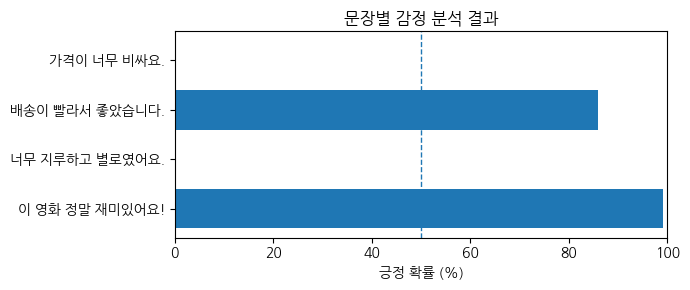

In [45]:
# ============================================================
# [실습 7-2] 여러 문장의 긍정 확률을 막대그래프로
# ------------------------------------------------------------
# 부정으로 판단된 문장은 (1 - 점수) 로 긍정 확률을 계산합니다.
# ============================================================

import matplotlib.pyplot as plt

문장들 = ["이 영화 정말 재미있어요!",
        "너무 지루하고 별로였어요.",
        "배송이 빨라서 좋았습니다.",
        "가격이 너무 비싸요."]

긍정확률 = []
for 문장 in 문장들:
    라벨, 점수 = 감정분석(문장)
    긍정확률.append(점수 * 100 if 라벨 == "긍정" else (1 - 점수) * 100)

plt.figure(figsize=(7, 3))
plt.barh(문장들, 긍정확률)
plt.xlim(0, 100)
plt.axvline(50, linestyle="--", linewidth=1)   # 50% 기준선
plt.xlabel("긍정 확률 (%)")
plt.title("문장별 감정 분석 결과")
plt.tight_layout()
plt.savefig("감정분석결과.png", dpi=100, bbox_inches="tight")
plt.show()


---
# STEP 8. 모델 고르는 법  (약 10분)

Hugging Face에는 공개 모델이 **200만 개가 넘습니다.**
그중에서 내 일에 맞는 모델을 고르는 것이 이 수업의 핵심 기술입니다.


### 모델 카드에서 반드시 확인할 것

| 확인할 것 | 왜 |
|---|---|
| **Task (작업 종류)** | text-classification 인지, 다른 작업인지 |
| **언어** | 한국어를 지원하는지 |
| **라벨** | LABEL_0 이 긍정인지 부정인지 |
| **라이선스** | 수업·과제에 써도 되는지 |
| **다운로드 수** | 많이 쓰이는 모델이 대체로 안전 |

### 모델 이름 읽는 법
```
WhitePeak / bert-base-cased-Korean-sentiment
   ↑              ↑
올린 사람      모델 이름 (구조 + 크기 + 용도가 이름에 들어 있음)
```


In [46]:
# ============================================================
# [실습 8-1] 같은 일을 하는 다른 모델과 비교해 보기
# ------------------------------------------------------------
# 모델을 바꿔도 코드는 그대로입니다. 이름만 바뀝니다.
# ※ 모델마다 라벨 이름이 다르므로 반드시 id2label 을 먼저 확인하세요.
# ============================================================

다른_분류기 = pipeline("text-classification",
                   model="matthewburke/korean_sentiment")

print("라벨 표 :", 다른_분류기.model.config.id2label)
print()

테스트 = "이 영화 정말 재미있어요!"
print("WhitePeak 모델   ->", 한국어_분류기(테스트))
print("matthewburke 모델 ->", 다른_분류기(테스트))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

라벨 표 : {0: 'LABEL_0', 1: 'LABEL_1'}

WhitePeak 모델   -> [{'label': 'LABEL_1', 'score': 0.9918510317802429}]
matthewburke 모델 -> [{'label': 'LABEL_1', 'score': 0.9733822345733643}]


---
# 오늘의 과제  (약 15분)


In [47]:
# ============================================================
# [과제 1] 내 문장 10개로 시험하기
# ------------------------------------------------------------
# TODO 1) 아래 리스트에 본인이 직접 쓴 문장 10개를 넣으세요.
#         - 확실한 긍정 3개 / 확실한 부정 3개 / 애매한 문장 4개
# TODO 2) 실행해서 결과를 확인하세요.
# TODO 3) 틀렸다고 생각되는 것이 몇 개인지 세어 보세요.
# ============================================================

내문장 = [
    # 확실한 긍정 3개
    "오늘 수업에서 새로운 내용을 배워서 뿌듯하고 기분이 좋다.",
    "과제를 생각보다 빨리 끝내서 마음이 편하고 만족스럽다.",
    "친구와 오랜만에 만나 즐겁게 이야기해서 정말 좋았다.",

    # 확실한 부정 3개
    "준비를 많이 했는데 시험을 망쳐서 속상하고 화가 난다.",
    "버스를 놓쳐서 지각할 것 같아 정말 짜증이 난다.",
    "하루 종일 오류가 해결되지 않아서 답답하고 힘들었다.",

    # 애매한 문장 4개
    "와, 정말 잘했다. 오늘도 역시 최고의 하루네.",
    "정말 대단하다. 이렇게 멋지게 망칠 줄은 몰랐다.",
    "기대하지 않았는데 생각보다 괜찮았다.",
    "시험이 끝나니 홀가분한데 결과를 생각하면 마음이 무겁다."
]

for i, 문장 in enumerate(내문장, start=1):
    라벨, 점수 = 감정분석(문장)
    표시 = "  " if 점수 >= 0.8 else "❓"   # 확신이 낮으면 물음표
    print(f"{표시} {i:2d}. [{라벨} {점수*100:5.1f}%]  {문장}")


    1. [긍정  99.2%]  오늘 수업에서 새로운 내용을 배워서 뿌듯하고 기분이 좋다.
    2. [긍정  99.2%]  과제를 생각보다 빨리 끝내서 마음이 편하고 만족스럽다.
    3. [긍정  99.2%]  친구와 오랜만에 만나 즐겁게 이야기해서 정말 좋았다.
    4. [부정  99.7%]  준비를 많이 했는데 시험을 망쳐서 속상하고 화가 난다.
    5. [부정  99.7%]  버스를 놓쳐서 지각할 것 같아 정말 짜증이 난다.
    6. [부정  99.7%]  하루 종일 오류가 해결되지 않아서 답답하고 힘들었다.
    7. [긍정  99.2%]  와, 정말 잘했다. 오늘도 역시 최고의 하루네.
    8. [부정  99.2%]  정말 대단하다. 이렇게 멋지게 망칠 줄은 몰랐다.
    9. [긍정  96.6%]  기대하지 않았는데 생각보다 괜찮았다.
   10. [부정  95.6%]  시험이 끝나니 홀가분한데 결과를 생각하면 마음이 무겁다.


### [과제 2] AI가 틀린 문장 찾아 설명하기

과제 1의 결과에서 **AI가 틀렸다고 생각되는 문장 2개**를 고르세요.

1. 어떤 문장이었고, AI는 뭐라고 답했나요?
2. 왜 틀렸을까요? (반어법 / 신조어 / 문맥 / 너무 짧은 문장 …)
3. HHugging Face에서 한글 감정 분류기 중 (화남, 두려움, 행복, 평온) 를 분류 할 수 있는 모델을 찾아 아래 문장을 분류한 결과를 출력하세요.

*<font color="red">"마음속에 거칠게 소용돌이치던 붉은 불길과 사지를 얼어붙게 만들던 차가운 어둠이 걷히고 나면, 마침내 온몸을 부드럽게 감싸는 따스한 빛과 깊은 밤 바다처럼 잔잔한 숨결이 찾아온다."</font>*


### 1번 답

#### 첫 번째 문장

**문장:**  
"와, 정말 잘했다. 오늘도 역시 최고의 하루네."

**AI 판단:**  
긍정 99.2%

**내가 의도한 의미:**  
실제로는 상황이 좋지 않은데 비꼬는 의미로 작성한 부정적인 문장입니다.

AI는 문장에 포함된 **"정말 잘했다", "최고의 하루"**와 같은 긍정적인 표현을 보고 긍정으로 판단한 것으로 생각합니다.

---

#### 두 번째 문장

**문장:**  
"정말 대단하다. 이렇게 멋지게 망칠 줄은 몰랐다."

**AI 판단:**  
긍정 99.2%

**내가 의도한 의미:**  
실제로는 일을 망쳤다는 부정적인 의미의 문장입니다.

문장 앞부분에 **"대단하다", "멋지게"**와 같은 긍정적인 표현이 들어 있어 AI가 이를 더 강하게 판단한 것으로 생각합니다.

---

### 2번 답

두 문장 모두 **긍정적인 표현과 부정적인 의미가 함께 들어 있기 때문에** AI가 실제 의도를 정확하게 판단하지 못한 것으로 생각합니다.

7번 문장에는 **"정말 잘했다", "최고의 하루"**와 같은 긍정적인 표현이 들어 있습니다. 저는 이 표현을 비꼬는 의미로 사용하였지만, AI는 문장에 나타난 긍정적인 단어를 그대로 판단한 것으로 보입니다.

8번 문장에도 **"대단하다", "멋지게"**와 같은 긍정적인 표현이 포함되어 있고, 뒤에는 **"망칠 줄은 몰랐다"**라는 부정적인 내용이 있습니다. 하지만 AI는 앞부분의 긍정적인 표현의 영향을 더 크게 받아 긍정으로 분류한 것으로 생각합니다.

이번 결과를 통해 감정 분석 모델이 일반적인 긍정·부정 문장은 잘 구분하지만, **반어법이나 비꼬는 표현처럼 문맥을 이해해야 하는 문장에서는 잘못 판단할 수 있다는 점**을 확인하였습니다.

---

### 3번 답

**사용 모델:**  
`jeonghyeon97/koBERT-Senti5`

이 모델은 한국어 문장을 다음과 같은 감정으로 분류할 수 있습니다.

- 화남
- 두려움
- 행복
- 평온
- 슬픔

#### 분석 결과

**예측 감정:** 행복  
**확률:** 73.57%

#### 전체 감정 확률

- 행복: **73.57%**
- 평온: **24.77%**
- 슬픔: **1.10%**
- 두려움: **0.43%**
- 화남: **0.14%**

#### 결과 해석

문장의 앞부분에는 **붉은 불길, 차가운 어둠**과 같이 부정적인 느낌을 주는 표현이 있습니다.

하지만 뒤로 갈수록 **따스한 빛, "잔잔한 숨결** 과 같이 따뜻하고 편안한 분위기의 표현이 나타납니다.

따라서 모델이 문장 전체에서 긍정적인 분위기를 더 강하게 판단하여 행복 73.57%로 분류한 것으로 생각합니다.



In [48]:
from transformers import pipeline, AutoTokenizer

# 사용할 Hugging Face 모델
모델이름 = "jeonghyeon97/koBERT-Senti5"

# KoBERT 토크나이저
토크나이저 = AutoTokenizer.from_pretrained(
    "monologg/kobert",
    trust_remote_code=True
)

# 감정 분류기 만들기
감정분류기 = pipeline(
    "text-classification",
    model=모델이름,
    tokenizer=토크나이저
)

# 교수님이 제시한 문장
문장 = """
마음속에 거칠게 소용돌이치던 붉은 불길과 사지를 얼어붙게 만들던
차가운 어둠이 걷히고 나면, 마침내 온몸을 부드럽게 감싸는 따스한 빛과
깊은 밤 바다처럼 잔잔한 숨결이 찾아온다.
"""

# 모든 감정 점수 확인
결과들 = 감정분류기(문장, top_k=None)

# 모델의 라벨을 한글로 변환
라벨변환 = {
    "LABEL_0": "화남",
    "LABEL_1": "두려움",
    "LABEL_2": "행복",
    "LABEL_3": "평온",
    "LABEL_4": "슬픔"
}

print("[전체 감정 분석 결과]")

for 결과 in 결과들:
    감정 = 라벨변환[결과["label"]]
    확률 = 결과["score"] * 100
    print(f"{감정}: {확률:.2f}%")

# 가장 확률이 높은 감정
최종결과 = max(결과들, key=lambda x: x["score"])

print()
print("예측 감정:", 라벨변환[최종결과["label"]])
print(f"확률: {최종결과['score'] * 100:.2f}%")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[전체 감정 분석 결과]
행복: 73.57%
평온: 24.77%
슬픔: 1.10%
두려움: 0.43%
화남: 0.14%

예측 감정: 행복
확률: 73.57%


---
# 자주 나는 오류와 해결법

| 증상(오류 메시지) | 원인 | 해결 방법 |
|---|---|---|
| `KeyError: 1` | 옛 예제의 `return_all_scores=True` 를 씀 | `top_k=None` 으로 바꾸기 |
| `OSError: Can't load ... config.json` | 모델 이름 오타 / 인터넷 끊김 | 모델 카드에서 이름을 복사해 붙여넣기 |
| 다운로드가 멈춘 것 같음 | 첫 실행은 원래 1~3분 | 진행 막대가 보이면 기다리기 |
| 한국어인데 결과가 이상함 | 영어 전용 모델을 씀 | 한국어 모델로 `model=` 변경 |
| `LABEL_0` 이 무슨 뜻인지 모름 | 모델마다 라벨 이름이 다름 | `config.id2label` 확인 + 확실한 문장으로 시험 |
| 그래프 한글이 □□□ | 한글 폰트 미설치 | [실습 7-1] 실행 |
| `NameError: 분류기 ...` | 위쪽 셀을 실행하지 않음 | [런타임] → [모두 실행] |
| 세션이 끊겨 모델이 사라짐 | 장시간 방치 | [런타임] → [모두 실행] (다시 내려받음) |

> 🙋 **막혔을 때** ① 오류 메시지 맨 아랫줄 읽기 → ② 위 표에서 찾기
> → ③ 옆 사람 화면과 비교 → ④ 손 들어 교수 부르기

---

# 더 알아보기

| 자료 | 주소 |
|---|---|
| Hugging Face 모델 허브 | https://huggingface.co/models |
| Hugging Face NLP 코스 (한국어) | https://huggingface.co/learn/nlp-course/ko/chapter1/1 |
| pipeline 공식 문서 | https://huggingface.co/docs/transformers/main_classes/pipelines |
| 오늘 쓴 한국어 모델 카드 | https://huggingface.co/WhitePeak/bert-base-cased-Korean-sentiment |
| 오픈소스 AI 현황 (2026) | https://huggingface.co/blog/huggingface/state-of-os-hf-spring-2026 |

---

# 이번 주 제출물

1. 이 노트북 파일 (`.ipynb`) — [파일] → [다운로드] → [.ipynb 다운로드]
2. `[실습 6-3]` 실행 결과 화면 캡처 (한글 라벨로 출력된 상태)
3. `[과제 1]` 내 문장 10개 결과, `[과제 2]` 1~3번 답

**제출 기한 : 다음 수업 전날 오후 11:59까지 ｜ 제출 위치 : 팀즈에 3주차 과제 생성**

※ 파일 이름은 `날짜(YYYYMMDD)_이름_3주차.ipynb` 형식으로 바꿔서 제출하세요.
　(예: 20260901_홍길동_3주차.ipynb)

---

# 다음 주 예고 — 4주차

**텍스트 태스크 — 번역과 요약**
오늘은 감정을 분류했지만, 다음 주에는 **긴 글을 요약하고 다른 언어로 번역**합니다.
바뀌는 것은 `pipeline()` 안의 작업 이름 한 단어뿐입니다.

```python
pipeline("summarization")     # 요약
pipeline("translation")       # 번역
```
